## Import Libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from inflation_forecast.pre_process import stationary_transform, report_missings, sample_split, remove_missing_col, create_ahead_lag
from inflation_forecast.visualization import visualize_series, visualize_loss, visualize_predict
from inflation_forecast.feature_engineering import create_fe_pipeline
from inflation_forecast.model import create_data_loaders, create_MLP, MLP_training, make_predict

## Data Pre-Process

In [2]:
# read the FRED_MD csv file, convert to pandas dataframe
root_dir = Path.cwd().parent
FRED_MD = pd.read_csv(str(root_dir) + "/data/FRED_MD/2026-02-MD.csv")
transforms = pd.read_csv(str(root_dir) + "/data/FRED_MD/transform.csv")

In [3]:
# conduct stationarity transformations
FRED_transformed = stationary_transform(FRED_MD, transforms)
# drop first two rows as they have abundant nan due to double difference
FRED_transformed = FRED_transformed.iloc[2:]
# drop last row as many variables of it has not updated
FRED_transformed = FRED_transformed.iloc[:-1]
# transform sasdate to pd.date format
FRED_transformed["sasdate"] = pd.to_datetime(FRED_transformed["sasdate"])
FRED_MD["sasdate"] = pd.to_datetime(FRED_MD["sasdate"])

In [4]:
# print missing value counts and percentage in each column
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

In [5]:
# drop columns with > 10% missing values
FRED_transformed = remove_missing_col(FRED_transformed)
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

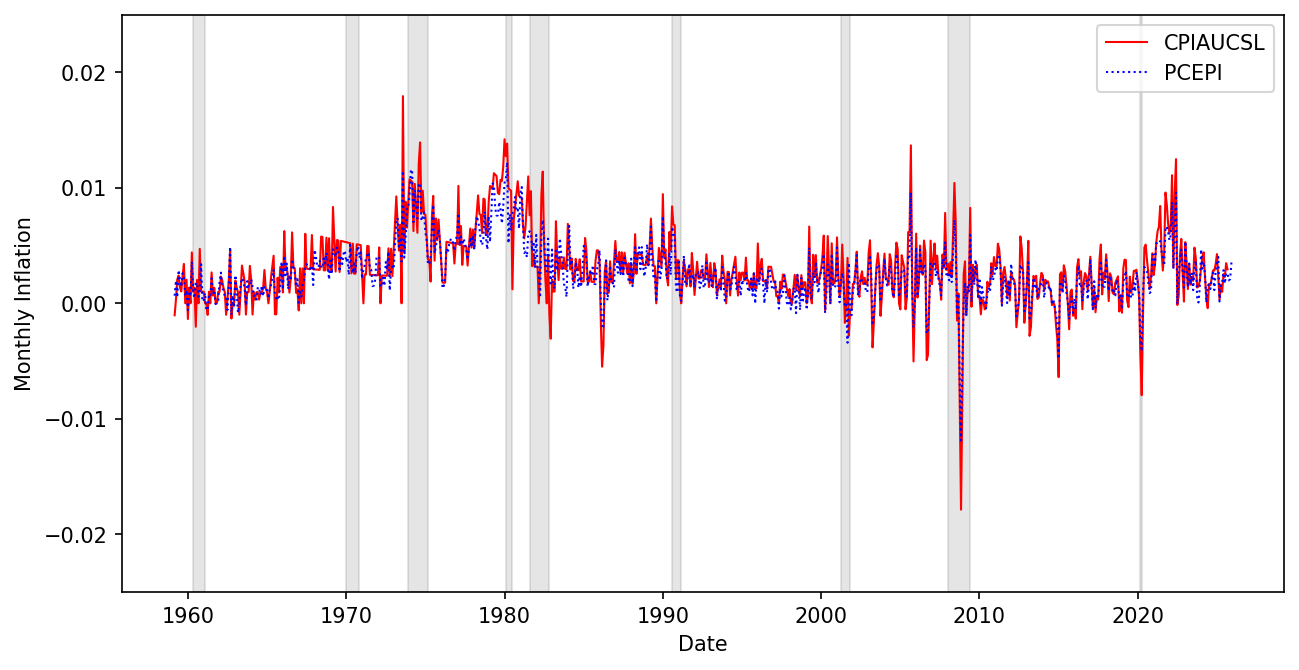

In [6]:
# plot CPIAUCSL and PCEPI over time
visualize_series(FRED_transformed, ["CPIAUCSL", "PCEPI"], "Monthly Inflation", -0.025, 0.025)

In [7]:
# split train and test set
FRED_transformed = FRED_transformed.drop(columns = ["sasdate"])
train_set, test_set = sample_split(FRED_transformed, 0.8)
# create feature engineering pipeline
feature_engineering = create_fe_pipeline()
# fit the feature engineering pipeline
feature_engineering.fit(train_set)
# uses the fitted pipeline to transform the whole dataset
FRED_transformed = feature_engineering.transform(FRED_transformed)

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.80)
pca.fit(FRED_transformed.loc[train_set.index])
FRED_PCA = pca.transform(FRED_transformed)
FRED_PCA = pd.DataFrame(FRED_PCA, columns=[f"PC{i+1}" for i in range(FRED_PCA.shape[1])])
FRED_PCA["CPIAUCSL"] = FRED_transformed["CPIAUCSL"]

## MLP

In [9]:
# create aheads and lags for MLP
max_lag = 6
max_ahead = 1
FRED_tt, targets = create_ahead_lag(FRED_PCA, "CPIAUCSL", max_ahead, max_lag)
# re-split the transformed dataset
train_set, test_set = sample_split(FRED_tt, 0.8)
# drop first max_lag rows and last max_ahead rows
train_set = train_set.iloc[max_lag:]
test_set = test_set.iloc[:-max_ahead]
drop_list = ["CPIAUCSL"]
for i in range(1, max_lag + 1):
    drop_list.append(f"CPIAUCSL_{i}L")
# extract X and Y from train set and test set
y_train = train_set[targets]
x_train = train_set.drop(columns = targets + drop_list)
y_test = test_set[targets]
x_test = test_set.drop(columns = targets + drop_list)

/Users/yuhaohuo/Desktop/code/d200_project/inflation_forecast/pre_process.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_frame[f"{column}_{i}L"] = new_frame[column].shift(i)


Epoch [1/500], Train MSE: 0.0980, Test MSE: 0.0609
Epoch [2/500], Train MSE: 0.0947, Test MSE: 0.0585
Epoch [3/500], Train MSE: 0.0915, Test MSE: 0.0562
Epoch [4/500], Train MSE: 0.0883, Test MSE: 0.0539
Epoch [5/500], Train MSE: 0.0852, Test MSE: 0.0518
Epoch [6/500], Train MSE: 0.0821, Test MSE: 0.0497
Epoch [7/500], Train MSE: 0.0791, Test MSE: 0.0477
Epoch [8/500], Train MSE: 0.0762, Test MSE: 0.0457
Epoch [9/500], Train MSE: 0.0733, Test MSE: 0.0438
Epoch [10/500], Train MSE: 0.0704, Test MSE: 0.0420
Epoch [11/500], Train MSE: 0.0674, Test MSE: 0.0402
Epoch [12/500], Train MSE: 0.0646, Test MSE: 0.0385
Epoch [13/500], Train MSE: 0.0617, Test MSE: 0.0369
Epoch [14/500], Train MSE: 0.0589, Test MSE: 0.0353
Epoch [15/500], Train MSE: 0.0561, Test MSE: 0.0338
Epoch [16/500], Train MSE: 0.0534, Test MSE: 0.0324
Epoch [17/500], Train MSE: 0.0508, Test MSE: 0.0310
Epoch [18/500], Train MSE: 0.0482, Test MSE: 0.0298
Epoch [19/500], Train MSE: 0.0458, Test MSE: 0.0286
Epoch [20/500], Train

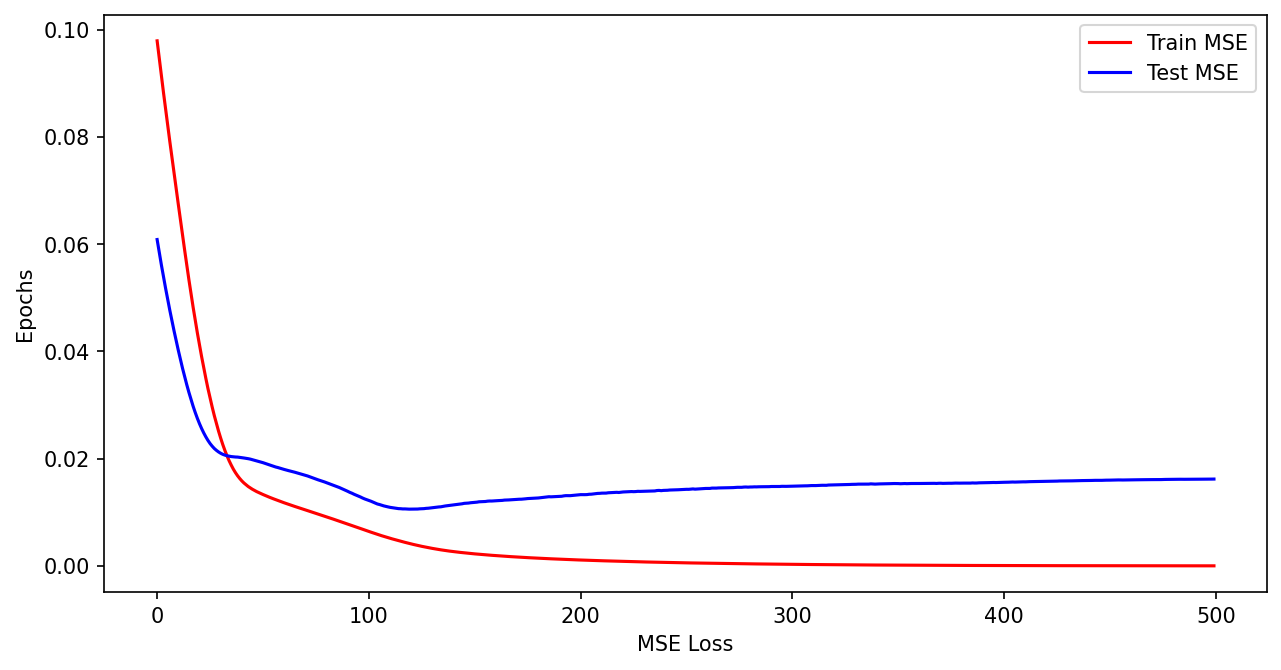

In [10]:
# train a MLP 
train_loader, test_loader = create_data_loaders(x_train, y_train, x_test, y_test, 128)
MLP = create_MLP(x_train, y_train)
train_loss_list, test_loss_list = MLP_training(MLP, train_loader, test_loader, 500, 0.0001)
visualize_loss(train_loss_list, test_loss_list)

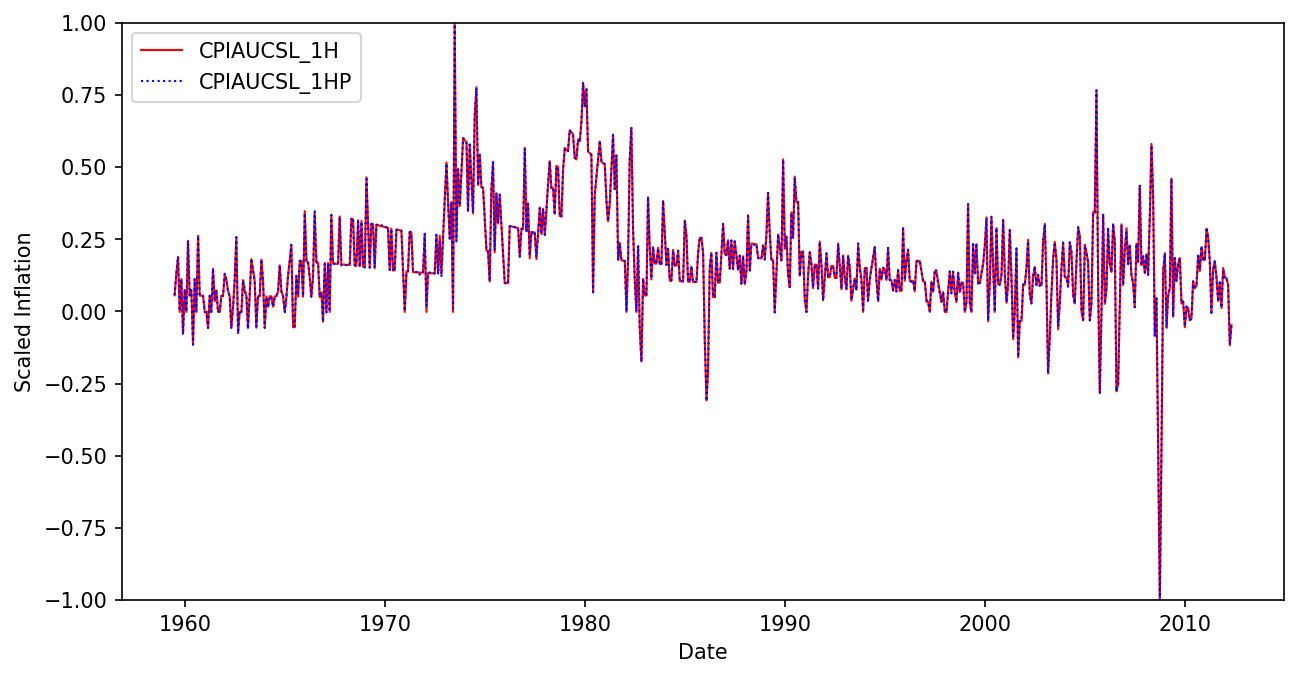

In [11]:
# plot prediction for training set
prediction = make_predict(MLP, x_train)
visualize_predict(prediction, y_train, 1, FRED_MD)

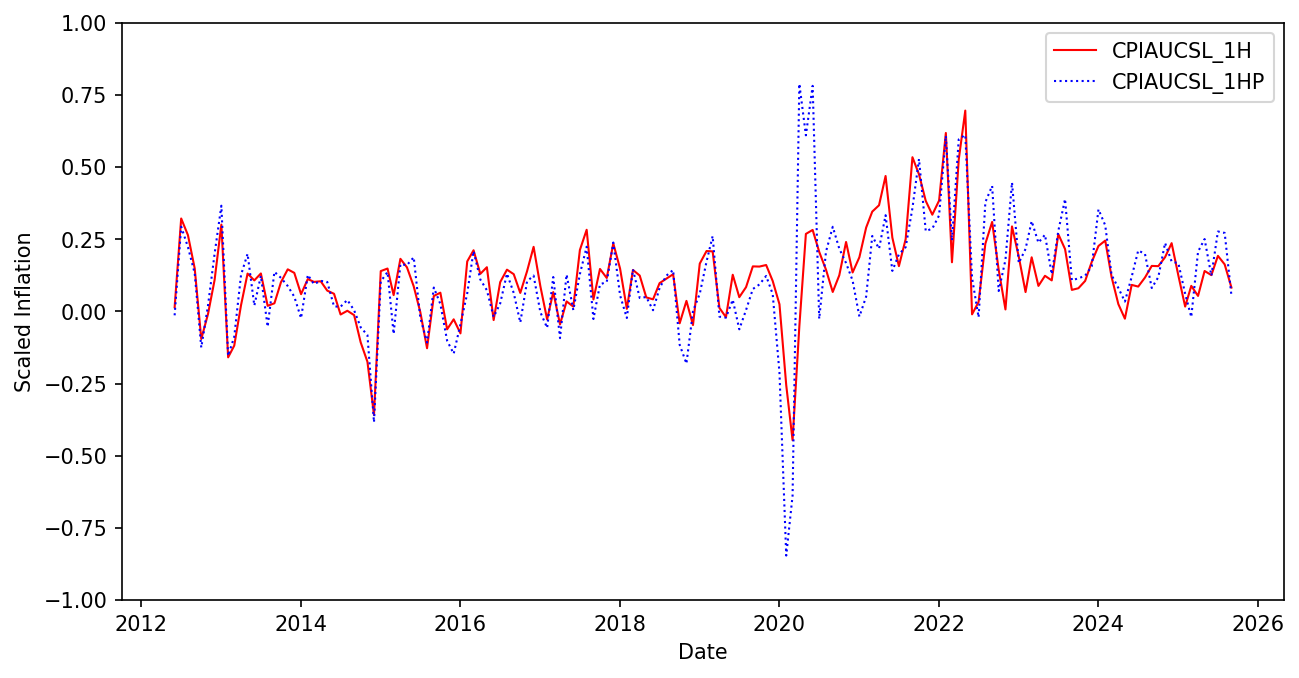

In [12]:
# plot prediction for testing set
prediction = make_predict(MLP, x_test)
visualize_predict(prediction, y_test, 1, FRED_MD)

## RNN

In [13]:
# create aheads and lags for RNN
max_lag = 0
max_ahead = 1
FRED_tt, targets = create_ahead_lag(FRED_PCA, "CPIAUCSL", max_ahead, max_lag)
# re-split the transformed dataset
train_set, test_set = sample_split(FRED_tt, 0.8)
# drop first max_lag rows and last max_ahead rows
train_set = train_set.iloc[max_lag:]
test_set = test_set.iloc[:-max_ahead]
drop_list = ["CPIAUCSL"]
for i in range(1, max_lag + 1):
    drop_list.append(f"CPIAUCSL_{i}L")
# extract X and Y from train set and test set
y_train = train_set[targets]
x_train = train_set.drop(columns = targets + drop_list)
y_test = test_set[targets]
x_test = test_set.drop(columns = targets + drop_list)

In [14]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # Apple Silicon Metal Performance Shaders
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # GPU
else:
    DEVICE = torch.device("cpu") # CPU

class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = 1,
            batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )
    
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        output = self.ffn(last_hidden)
        return output

RNN = LSTM(input_size=x_train.shape[1], hidden_size=32,  output_size=y_train.shape[1]).to(DEVICE)

In [15]:
X_train = torch.tensor(x_train.values, dtype=torch.float32)
Y_train = torch.tensor(y_train.values, dtype=torch.float32)
X_test = torch.tensor(x_test.values, dtype=torch.float32)
Y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [16]:
class WindowData(Dataset):

    def __init__(self, X, Y, window):

        self.X = X
        self.Y = Y
        self.window = window

    def __len__(self):

        return len(self.X) - self.window

    def __getitem__(self, idx):

        X_seq = self.X[idx:idx+self.window]
        Y_target = self.Y[idx+self.window]

        return X_seq, Y_target

window_size = 48

train_dataset = WindowData(X_train, Y_train, window_size)
test_dataset = WindowData(X_test, Y_test, window_size)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Epoch [1/500], Train MSE: 0.0376, Test MSE: 0.0244
Epoch [2/500], Train MSE: 0.0348, Test MSE: 0.0234
Epoch [3/500], Train MSE: 0.0329, Test MSE: 0.0230
Epoch [4/500], Train MSE: 0.0316, Test MSE: 0.0231
Epoch [5/500], Train MSE: 0.0306, Test MSE: 0.0234
Epoch [6/500], Train MSE: 0.0297, Test MSE: 0.0236
Epoch [7/500], Train MSE: 0.0287, Test MSE: 0.0237
Epoch [8/500], Train MSE: 0.0275, Test MSE: 0.0236
Epoch [9/500], Train MSE: 0.0260, Test MSE: 0.0232
Epoch [10/500], Train MSE: 0.0243, Test MSE: 0.0228
Epoch [11/500], Train MSE: 0.0223, Test MSE: 0.0222
Epoch [12/500], Train MSE: 0.0199, Test MSE: 0.0217
Epoch [13/500], Train MSE: 0.0176, Test MSE: 0.0212
Epoch [14/500], Train MSE: 0.0160, Test MSE: 0.0202
Epoch [15/500], Train MSE: 0.0150, Test MSE: 0.0187
Epoch [16/500], Train MSE: 0.0138, Test MSE: 0.0171
Epoch [17/500], Train MSE: 0.0125, Test MSE: 0.0152
Epoch [18/500], Train MSE: 0.0113, Test MSE: 0.0136
Epoch [19/500], Train MSE: 0.0101, Test MSE: 0.0122
Epoch [20/500], Train

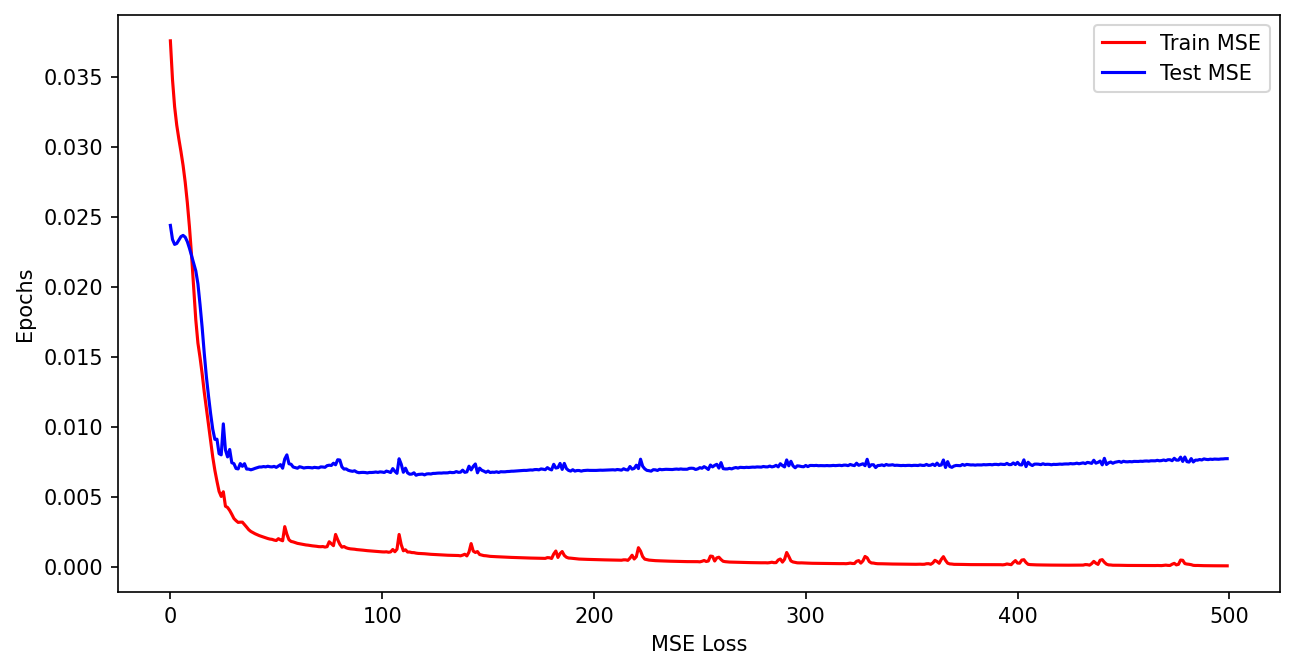

In [17]:
train_loss_list, test_loss_list = MLP_training(RNN, train_loader, test_loader, 500, 0.001)
visualize_loss(train_loss_list, test_loss_list)

/var/folders/qb/pd0pzd3x0jj2c_2nkn2hmrxw0000gn/T/ipykernel_55342/25174975.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X_tensor = torch.tensor(X_tensor, dtype=torch.float32)


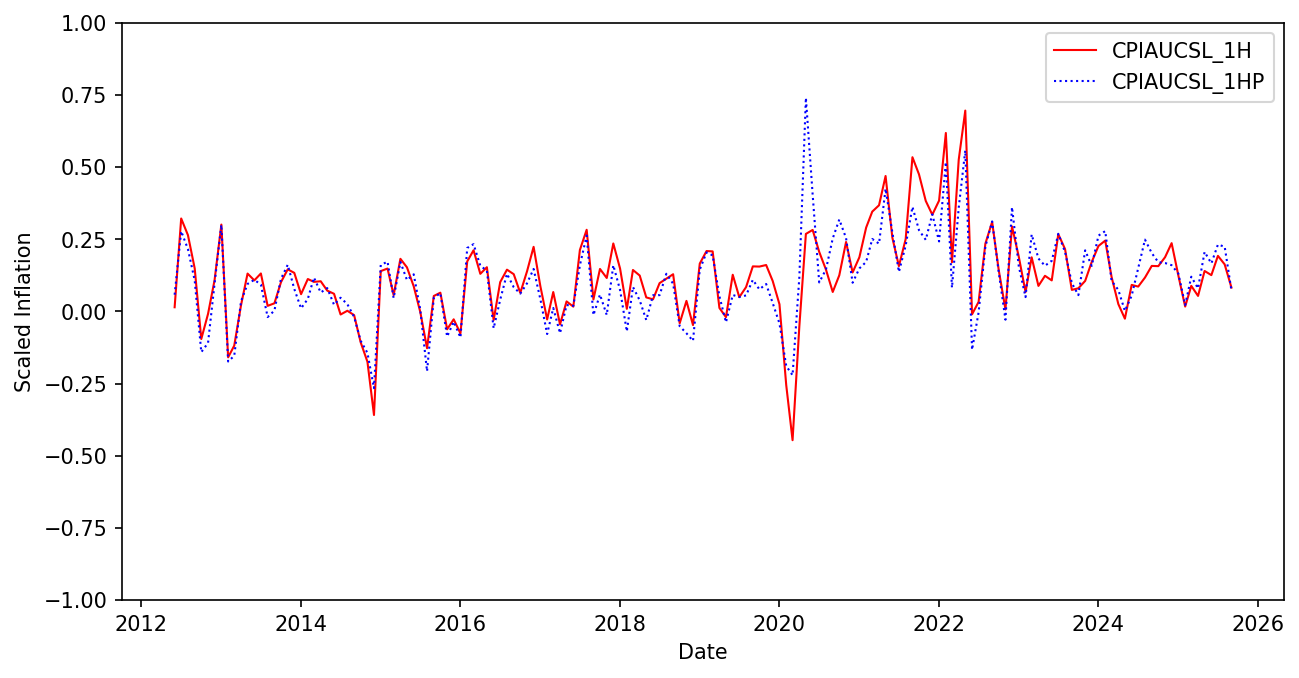

In [18]:
window = 48
X_combined = pd.concat(
    [x_train.tail(window), x_test]
)
X = X_combined.to_numpy()
X_tensor = []
for i in range(len(X) - window):
    X_tensor.append(X[i:i+window])
X_tensor = torch.tensor(X_tensor, dtype=torch.float32)
prediction = RNN(X_tensor.to(DEVICE))
prediction = pd.DataFrame(prediction.detach().to("cpu").numpy())
visualize_predict(prediction, y_test, 1, FRED_MD)

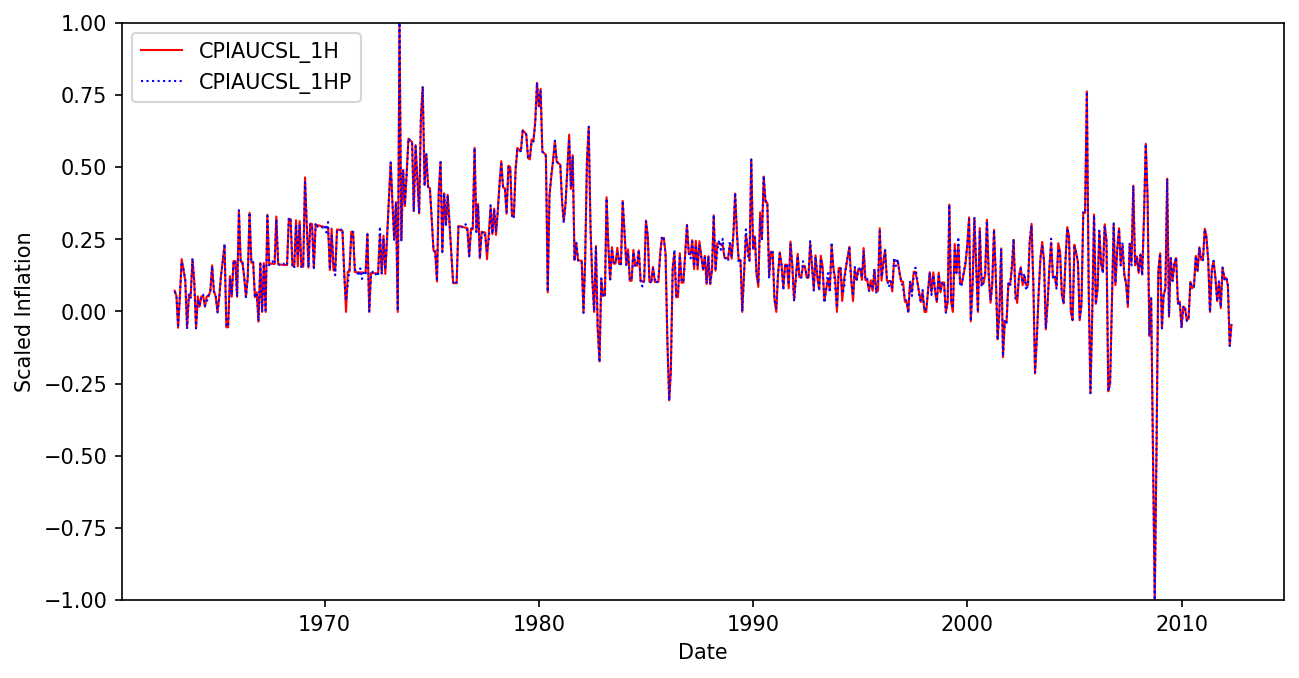

In [19]:
window = 48
X = x_train.to_numpy()
X_tensor = []
for i in range(len(X) - window):
    X_tensor.append(X[i:i+window])
X_tensor = torch.tensor(X_tensor, dtype=torch.float32)
prediction = RNN(X_tensor.to(DEVICE))
prediction = pd.DataFrame(prediction.detach().to("cpu").numpy())
visualize_predict(prediction, y_train[48:], 1, FRED_MD)